In [1]:
# Environment setup (local version of the SigLIP 2 Colab cell)
# Tested on the RTX 3070 Ti with ViT-L/16 @ 512px for inference only.
import os, shutil, subprocess, sys

# Hide the GPU from TensorFlow. big_vision's pp pipeline imports TF, and a
# CUDA-enabled TF in the same process as JAX causes CUDA_ERROR_INVALID_IMAGE
# (the two libraries bring incompatible CUDA runtimes). TF is only used for
# CPU-side preprocessing ops here, so we don't lose anything by hiding the GPU.
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '0')   # JAX still sees the GPU
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')   # quiet INFO/WARNING spam

# Don't let JAX preallocate the whole 8 GB up front. Grow on demand so the X
# server (~700 MB) and other small allocations don't trigger spurious OOMs.
os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')
os.environ.setdefault('XLA_PYTHON_CLIENT_MEM_FRACTION', '0.95')

import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')
assert tf.config.get_visible_devices('GPU') == [], 'TF should not see any GPU'
print('TF', tf.__version__, '— GPU hidden, will run on CPU')

if shutil.which('nvidia-smi'):
    subprocess.run(['nvidia-smi'], check=False)

# The big_vision repo was cloned at the project root (next to this notebook).
# Clone it only if it isn't there yet — keeps re-runs idempotent.
if not os.path.isdir('big_vision'):
    subprocess.run(
        ['git', 'clone', '--quiet', '--branch=main', '--depth=1',
         'https://github.com/google-research/big_vision'],
        check=True,
    )

# All Python deps (jax[cuda12], flax==0.8.5, tf-cpu, gsutil, clu, flaxformer,
# panopticapi, …) are already in the `siglip2` conda env. No pip step here.

# big_vision expects to be imported as a top-level package; the package
# directory lives at ./big_vision/big_vision, so we cd one level in.
if os.path.basename(os.getcwd()) != 'big_vision':
    os.chdir('big_vision')
print('cwd:', os.getcwd())

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import jax
import jax.numpy as jnp
import ml_collections

print('jax', jax.__version__, '| devices:', jax.devices(), '| backend:', jax.default_backend())

# The Colab uses google.colab.output._publish for the interactive "Pretty demo"
# cell. We stub it so the rest of the notebook imports cleanly; when we port
# the pretty-demo cell we'll replace this with an IPython.display-based shim.
class _PublishStub:
    def javascript(self, *a, **kw): pass
    def css(self, *a, **kw): pass
    def html(self, s, *a, **kw):
        from IPython.display import HTML, display
        display(HTML(s))
publish = _PublishStub()



TF 2.20.0 — GPU hidden, will run on CPU
Wed May 20 15:31:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.133.07             Driver Version: 570.133.07     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3070 Ti     Off |   00000000:B3:00.0  On |                  N/A |
|  0%   38C    P8             15W /  310W |     811MiB /   8192MiB |     39%      Default |
|                                         |                        |                  N/A |
+-------

In [2]:
# Pick your hero: (WHEN CHANGING THIS, RERUN IMAGE/TEXT EMBEDDING CELLS)
# Give this cell 1-3mins.

# VARIANT, RES = 'B/32', 256
# VARIANT, RES = 'B/16', 224
# VARIANT, RES = 'B/16', 256
# VARIANT, RES = 'B/16', 384
VARIANT, RES = 'B/16', 512
# VARIANT, RES, N_PATCHES = 'B/16', 'naflex', 256
# VARIANT, RES = 'L/16', 256
# VARIANT, RES = 'L/16', 384
# VARIANT, RES = 'L/16', 512  # doesn't fit on 8 GB in fp32
# VARIANT, RES = 'So400m/16', 256
# VARIANT, RES = 'So400m/16', 384
# VARIANT, RES = 'So400m/16', 512
# VARIANT, RES, N_PATCHES = 'So400m/16', 'naflex', 256
# VARIANT, RES = 'So400m/14', 224
# VARIANT, RES = 'So400m/14', 384
# VARIANT, RES = 'g-opt/16', 256
# VARIANT, RES = 'g-opt/16', 384

CKPT = f'siglip2_{VARIANT.lower().replace("/", "")}_{RES}.npz'
TXTVARIANT, PATCH_SIZE = VARIANT.split('/')
EMBDIM = {'B': 768, 'L': 1024, 'So400m': 1152, 'g-opt': 1536}[TXTVARIANT]
# Note: The g-opt vision encoder is paired with a So400m text encoder
TXTVARIANT = 'So400m' if TXTVARIANT == 'g-opt' else TXTVARIANT
PATCH_SIZE = int(PATCH_SIZE)
VOCAB = 256_000
SEQLEN = 64

# It is significantly faster to first copy the checkpoint (30s vs 8m30 for B and 1m vs ??? for L)
!test -f /tmp/{CKPT} || gsutil cp gs://big_vision/siglip2/{CKPT} /tmp/

import big_vision.models.proj.image_text.two_towers as model_mod

model_cfg = ml_collections.ConfigDict(dict(
    image_model='vit',
    image=dict(
        pool_type='map',
        scan=True,
        variant=VARIANT,
    ),
    text_model='proj.image_text.text_transformer',
    text=dict(
        scan=True,
        variant=TXTVARIANT,
        vocab_size=256_000,
    ),
    out_dim=[None, EMBDIM],
    bias_init=-10,  # without this arg, no "b" param is added
))
if RES == 'naflex':
  model_cfg.image_model = 'proj.image_text.naflex_vit'
  model_cfg.image = dict(
      pool_type='map',
      nposemb=16,
      posemb='learn_2d',
      variant='B'
  )

model = model_mod.Model(**model_cfg)

# Using `init_params` is slower but will lead to `load` below performing sanity-checks.
# init_params = jax.jit(model.init, backend="cpu")(jax.random.PRNGKey(42), jnp.zeros([1, RES, RES, 3], jnp.float32), jnp.zeros([1, SEQLEN], jnp.int32))['params']
init_params = None  # Faster but bypasses loading sanity-checks.

params = model_mod.load(init_params, f'/tmp/{CKPT}', model_cfg)

/home/valenbonas/miniconda3/envs/siglip2/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://big_vision/siglip2/siglip2_b16_512.npz...
/ [1 files][  1.4 GiB/  1.4 GiB]    5.6 MiB/s                                   
Operation completed over 1 objects/1.4 GiB.                                      


In [3]:
import os, glob, numpy as np
from PIL import Image

import big_vision.pp.builder as pp_builder
import big_vision.pp.ops_general
import big_vision.pp.ops_image
import big_vision.pp.ops_text
import big_vision.pp.proj.image_text.ops_naflex
import big_vision.pp.proj.paligemma.ops

MY_IMAGE_DIR = '/home/valenbonas/Documents/Investigacion_doctorado/Siglip2_test/images/selected/'
paths = sorted(glob.glob(os.path.join(MY_IMAGE_DIR, '*.[jp][pn]*g'))
              + glob.glob(os.path.join(MY_IMAGE_DIR, '*.webp')))
print(f'Found {len(paths)} images')

images = [Image.open(p).convert('RGB') for p in paths]

# Two preprocessing paths:
#   * RES = int   -> fixed square: resize to RES x RES, scale to [-1, 1].
#   * RES == 'naflex' -> variable aspect: emit up to N_PATCHES patches of size
#     PATCH_SIZE x PATCH_SIZE, plus a 'type' mask (1 = real, 0 = pad) and
#     per-patch (yidx, xidx) row/column indices that the NaFlex ViT consumes
#     in place of fixed positional embeddings.
def make_naflex_pp(n_patches, patch_size):
    return pp_builder.get_preprocess_fn('|'.join((
        'value_range(-1, 1)',
        f'resize_to_sequence({patch_size}, {n_patches}, outkey="image")',
        f'patchify({patch_size}, key="image")',
        'flatten(["image"])',
        f'pad_to_shape(key="image/patches", shape=({n_patches}, None))',
        f'pad_to_shape(key="image/type",    shape=({n_patches},))',
        f'pad_to_shape(key="image/yidx",    shape=({n_patches},))',
        f'pad_to_shape(key="image/xidx",    shape=({n_patches},))',
        'tuplify(["image/patches", "image/type", "image/yidx", "image/xidx"], "image")',
    )))

if RES == 'naflex':
    pp_img = make_naflex_pp(N_PATCHES, PATCH_SIZE)
    # Each image -> tuple(patches, type, yidx, xidx). Stack across N images.
    per_image = [pp_img({'image': np.array(im)})['image'] for im in images]
    imgs = tuple(np.stack(arrs) for arrs in zip(*per_image))
    print('imgs (naflex 4-tuple):',
          'patches', imgs[0].shape,
          '| type', imgs[1].shape,
          '| yidx', imgs[2].shape,
          '| xidx', imgs[3].shape)
else:
    pp_img = pp_builder.get_preprocess_fn(f'resize({RES})|value_range(-1, 1)')
    imgs = np.array([pp_img({'image': np.array(im)})['image'] for im in images])
    print('imgs', imgs.shape)

zimg, _, out = model.apply({'params': params}, imgs, None)
print('zimg', zimg.shape, '| dtype', zimg.dtype)

Found 5 images
imgs (5, 512, 512, 3)
zimg (5, 768) | dtype float32


In [4]:
# ----------------------------------------------------------------------------
# Zero-shot: embed candidate text labels through the text tower.
#
# Edit LABELS to match what's in your image set. The "a photo of …" prefix is
# the standard zero-shot prompt and tends to work better than the bare noun.
# ----------------------------------------------------------------------------
LABELS = ['an image of an area chart',
          'an image of a bar chart',
          'an image of a line chart',
          'an image of a pie chart']

# SigLIP 2 was trained on lowercased texts.
# Tokenizer = gemma (256k vocab); pad/truncate to SEQLEN tokens (=64 from cell 1).
pp_txt = pp_builder.get_preprocess_fn(
    f'lower(key="text")|tok(length={SEQLEN}, model="gemma", bos="no", eos="sticky", key="text")'
)
txts = np.array([pp_txt({'text': s})['text'] for s in LABELS])
print('txts shape:', txts.shape, '| dtype:', txts.dtype)

# Run the text tower only (pass images=None). Returns ztxt of shape (n_labels, EMBDIM)
# plus an `out` dict with the learned temperature `t` and bias `b`.
_, ztxt, out = model.apply({'params': params}, None, txts)
ztxt = np.asarray(ztxt)
print('ztxt shape:', ztxt.shape, '| dtype:', ztxt.dtype)

# Note: `out['t']` and `out['b']` are 1-element arrays (not Python floats), so
# we use np.asarray(...).item() — Python's float() requires a 0-d array in
# JAX 0.4+ and would raise "Only scalar arrays can be converted to Python scalars".
t_scalar = np.asarray(out['t']).item()
b_scalar = np.asarray(out['b']).item()
print(f'learned scoring params:  t = {t_scalar:.3f}   b = {b_scalar:.3f}')

txts shape: (4, 64) | dtype: int32
ztxt shape: (4, 768) | dtype: float32
learned scoring params:  t = 112.548   b = -16.772


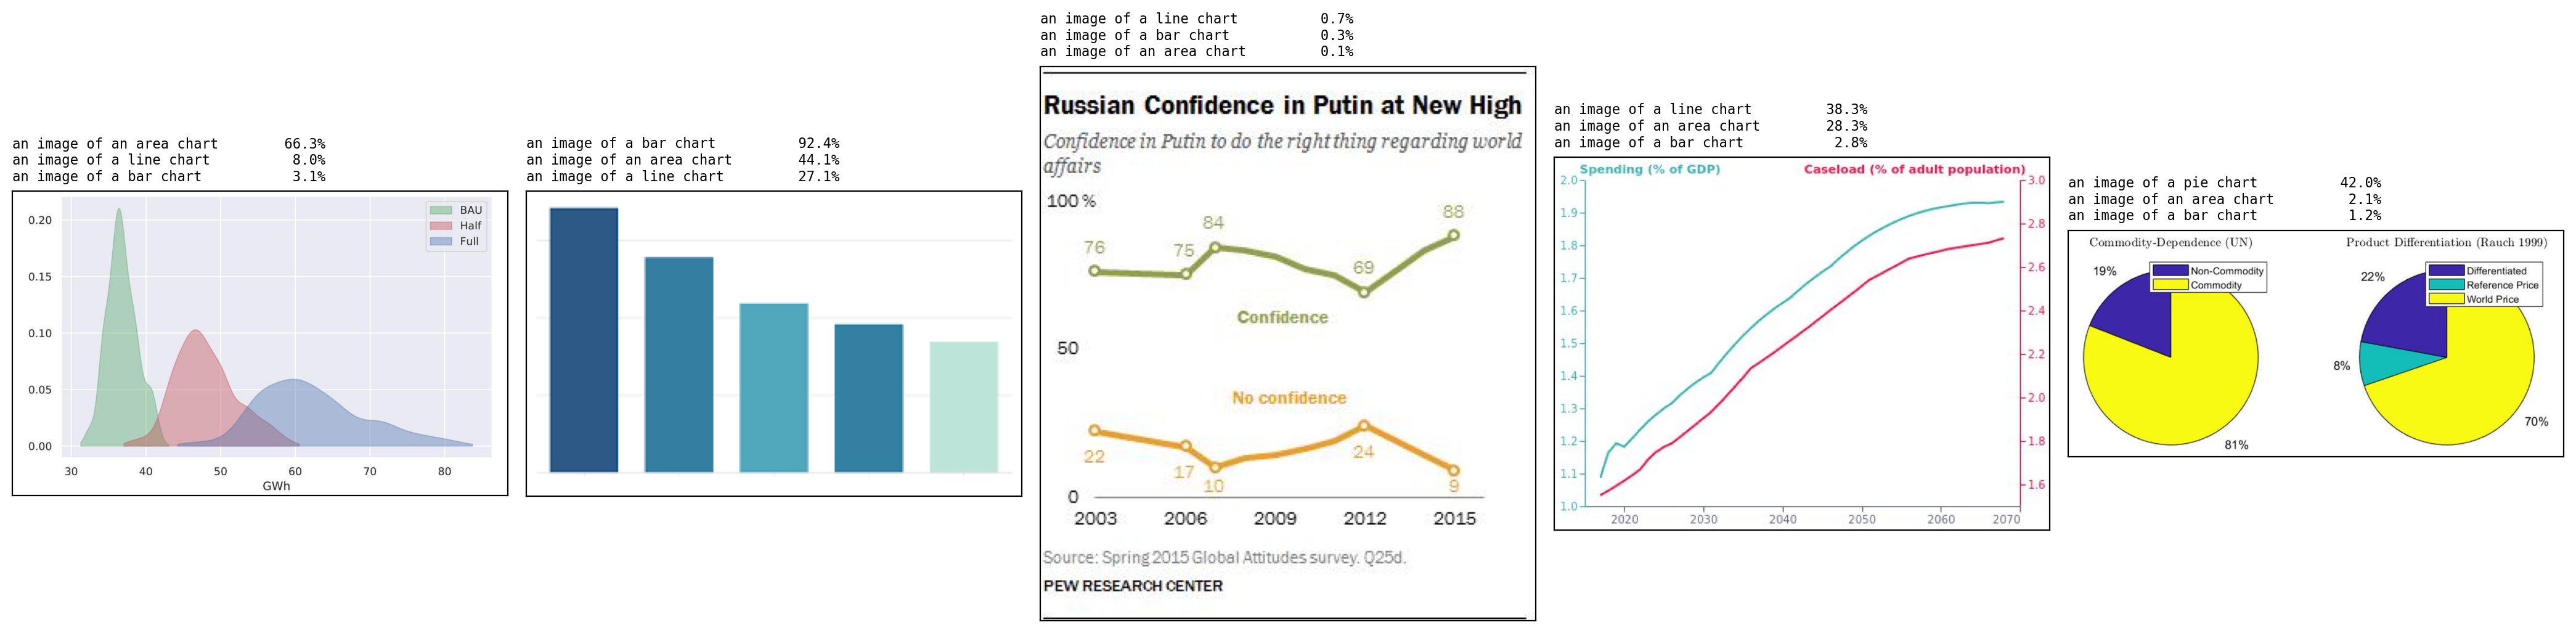


Full score matrix (rows = images, cols = labels):

image                             an image of an  an image of a   an image of a   an image of a 
------------------------------------------------------------------------------------------------
area0_xiv.jpg                              66.3%            3.1%            8.0%            0.5%
bar_chart.jpg                              44.1%           92.4%           27.1%            1.4%
line_chart0_qa.jpg                          0.1%            0.3%            0.7%            0.0%
line_chart4_vl.jpg                         28.3%            2.8%           38.3%            0.3%
pie_chart2_xiv.jpg                          2.1%            1.2%            0.4%           42.0%

Top-1 predictions:
  area0_xiv.jpg                     →  an image of an area chart            p = 66.3%
  bar_chart.jpg                     →  an image of a bar chart              p = 92.4%
  line_chart0_qa.jpg                →  an image of a line chart             p

In [5]:
# ----------------------------------------------------------------------------
# Zero-shot: score every (image, label) pair with the SigLIP sigmoid rule:
#       score = sigmoid( zimg · ztxt^T * t + b )
# Then visualise: each image + its top-K predicted labels with probabilities.
# ----------------------------------------------------------------------------
TOP_K = 3
t = np.asarray(out['t']).item()
b = np.asarray(out['b']).item()

logits = np.asarray(zimg) @ ztxt.T * t + b          # shape: (n_images, n_labels)
probs  = 1.0 / (1.0 + np.exp(-logits))              # sigmoid; independent per pair

# --- visual summary
n = len(paths)
cols = min(n, 5)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4.2 * cols, 5 * rows), squeeze=False)
for ax, p, im, prob_row in zip(axes.flat, paths, images, probs):
    top_idx = np.argsort(-prob_row)[:TOP_K]
    ax.imshow(im)
    ax.set_xticks([]); ax.set_yticks([])
    title_lines = [f'{LABELS[j]:<32}{prob_row[j]*100:5.1f}%' for j in top_idx]
    ax.set_title('\n'.join(title_lines), fontsize=8, loc='left', fontfamily='monospace')
for ax in axes.flat[n:]:
    ax.axis('off')
plt.tight_layout(); plt.show()

# --- numeric summary (full matrix)
print(f'\nFull score matrix (rows = images, cols = labels):\n')
hdr = f'{"image":<32s}' + ''.join(f'  {l[:14]:>14s}' for l in LABELS)
print(hdr); print('-' * len(hdr))
for p, prob_row in zip(paths, probs):
    print(f'{os.path.basename(p):<32s}' + ''.join(f'  {x*100:>13.1f}%' for x in prob_row))

# --- best-match summary
print('\nTop-1 predictions:')
for p, prob_row in zip(paths, probs):
    j = int(np.argmax(prob_row))
    print(f'  {os.path.basename(p):<32s}  →  {LABELS[j]:<35s}  p = {prob_row[j]*100:.1f}%')